## Title
EDA - Analisis univariable

### By:
Mateo Soto

### Date:
20-08-2026

### Description:

Análisis detallado de cada atributo del dataset de precios de casas en Boston: tipo de dato,
nulos, duplicados, ruido, estadística descriptiva, distribución, y reglas de validación, como
base para las etapas de preparación de datos y feature engineering.


## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.float_format", "{:.2f}".format)

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Pandas version:  3.0.5


## 💾 Load data

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet", engine="pyarrow"
)

In [28]:
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       448 non-null    int64  
 1   crim     443 non-null    float64
 2   zn       446 non-null    float64
 3   indus    442 non-null    float64
 4   chas     446 non-null    boolean
 5   nox      444 non-null    float64
 6   rm       442 non-null    float64
 7   age      444 non-null    float64
 8   dis      442 non-null    float64
 9   rad      444 non-null    Int64  
 10  tax      443 non-null    float64
 11  ptratio  446 non-null    float64
 12  black    445 non-null    float64
 13  lstat    447 non-null    float64
 14  medv     432 non-null    float64
dtypes: Int64(1), boolean(1), float64(12), int64(1)
memory usage: 50.4 KB


In [29]:
boston_df.shape

(448, 15)

In [30]:
boston_df.sample(5)

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
83,123,0.09,0.00,25.65,False,0.58,5.96,92.90,2.09,2,188.00,19.10,378.09,17.93,20.50
238,361,4.54,0.00,18.10,False,0.77,6.40,88.00,2.52,24,666.00,20.20,374.56,7.79,25.00
446,494,0.17,0.00,9.69,False,0.58,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,21.80
64,94,0.03,28.00,15.04,False,0.46,6.21,28.90,3.67,4,270.00,18.20,396.33,6.21,25.00
6,12,0.12,12.50,7.87,False,0.52,6.01,82.90,6.23,5,311.00,15.20,396.90,13.27,NaN


In [4]:
# filas exactamente duplicadas
print("Filas duplicadas:", boston_df.duplicated().sum())

# columnas duplicadas (mismo contenido en dos columnas distintas)
duplicated_cols = boston_df.T.duplicated()
print("Columnas duplicadas:", duplicated_cols[duplicated_cols].index.tolist())

Filas duplicadas: 80
Columnas duplicadas: []


### Duplicados — hallazgo relevante

- Filas exactamente duplicadas (incluyendo `ID`): **80**
- Filas duplicadas en las 14 variables reales, ignorando `ID`: **90**
- `ID` no es un identificador verdaderamente único: solo 343 valores únicos en 448 filas.

Esto sugiere que el dataset fue construido concatenando datos de más de una fuente o de una
misma fuente cargada más de una vez, generando registros duplicados con IDs tanto repetidos
como distintos para el mismo dato real. **Esta es una decisión importante para Feature
Engineering**: debe evaluarse si eliminar los duplicados (probablemente sí, ya que inflan
artificialmente el tamaño efectivo del dataset y podrían sesgar el entrenamiento hacia esos
registros repetidos).

In [5]:
boston_df.isnull().sum()
(boston_df.isnull().mean() * 100).round(2)  # % de nulos, no solo conteo

ID        0.00
crim      1.12
zn        0.45
indus     1.34
chas      0.45
nox       0.89
rm        1.34
age       0.89
dis       1.34
rad       0.89
tax       1.12
ptratio   0.45
black     0.67
lstat     0.22
medv      3.57
dtype: float64

## Target Variable = medv (valor mediano de la vivienda, en miles de USD)

In [ ]:
column = "crim"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   443.00
mean      3.86
std       8.21
min       0.01
25%       0.09
50%       0.35
75%       4.15
max      73.53
Name: crim, dtype: float64
Skewness: 4.430
Kurtosis: 27.342


In [ ]:
column = "zn"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   446.00
mean      9.15
std      20.79
min       0.00
25%       0.00
50%       0.00
75%       0.00
max     100.00
Name: zn, dtype: float64
Skewness: 2.640
Kurtosis: 6.489


In [ ]:
column = "indus"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   442.00
mean     12.03
std       7.07
min       0.74
25%       5.86
50%      10.01
75%      18.10
max      27.74
Name: indus, dtype: float64
Skewness: 0.133
Kurtosis: -1.324


In [ ]:
column = "nox"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   444.00
mean      0.57
std       0.12
min       0.39
25%       0.47
50%       0.54
75%       0.65
max       0.87
Name: nox, dtype: float64
Skewness: 0.637
Kurtosis: -0.124


In [ ]:
column = "rm"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   442.00
mean      6.23
std       0.68
min       3.56
25%       5.88
50%       6.15
75%       6.54
max       8.72
Name: rm, dtype: float64
Skewness: 0.409
Kurtosis: 2.016


In [ ]:
column = "age"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   444.00
mean     71.26
std      27.67
min       6.00
25%      50.67
50%      82.15
75%      95.00
max     100.00
Name: age, dtype: float64
Skewness: -0.779
Kurtosis: -0.672


In [ ]:
column = "dis"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   442.00
mean      3.49
std       1.90
min       1.13
25%       1.98
50%       2.78
75%       4.56
max      10.71
Name: dis, dtype: float64
Skewness: 1.056
Kurtosis: 0.403


In [ ]:
column = "tax"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   443.00
mean    418.36
std     171.61
min     188.00
25%     284.50
50%     384.00
75%     666.00
max     711.00
Name: tax, dtype: float64
Skewness: 0.552
Kurtosis: -1.285


In [ ]:
column = "ptratio"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   446.00
mean     18.40
std       2.24
min      12.60
25%      16.80
50%      19.00
75%      20.20
max      21.20
Name: ptratio, dtype: float64
Skewness: -0.729
Kurtosis: -0.613


In [ ]:
column = "black"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   445.00
mean    347.80
std      99.92
min       3.50
25%     368.74
50%     391.23
75%     395.99
max     396.90
Name: black, dtype: float64
Skewness: -2.378
Kurtosis: 4.373


In [ ]:
column = "lstat"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   447.00
mean     13.19
std       7.24
min       1.73
25%       7.53
50%      12.03
75%      17.28
max      37.97
Name: lstat, dtype: float64
Skewness: 0.816
Kurtosis: 0.346


In [ ]:
column = "medv"

# Tendencia central y dispersión
print(boston_df[column].describe())

# Skewness y kurtosis
print(f"Skewness: {boston_df[column].skew():.3f}")
print(f"Kurtosis: {boston_df[column].kurtosis():.3f}")

count   432.00
mean     21.99
std       9.22
min       5.00
25%      16.10
50%      20.60
75%      24.70
max      50.00
Name: medv, dtype: float64
Skewness: 1.154
Kurtosis: 1.661


In [24]:
numeric_cols = list(boston_df.select_dtypes(include=["number"]).columns)
numeric_cols.remove("ID")

summary = pd.DataFrame(
    {
        "skewness": boston_df[numeric_cols].skew(),
        "kurtosis": boston_df[numeric_cols].kurtosis(),
        "% nulos": (boston_df[numeric_cols].isna().mean() * 100).round(2),
    }
)
summary

,skewness,kurtosis,% nulos
crim,4.43,27.34,1.12
zn,2.64,6.49,0.45
indus,0.13,-1.32,1.34
nox,0.64,-0.12,0.89
rm,0.41,2.02,1.34
age,-0.78,-0.67,0.89
dis,1.06,0.40,1.34
rad,0.95,-0.99,0.89
tax,0.55,-1.28,1.12
ptratio,-0.73,-0.61,0.45


## Resumen — Variables numéricas (Skewness, Kurtosis y forma de distribución)

| Variable | Skewness | Kurtosis | Interpretación de forma | Tipo de distribución aproximada |
|---|---|---|---|---|
| `crim` | 4.43 | 27.34 | Asimetría extrema a la derecha, colas muy pesadas | Log-normal — pocas zonas de criminalidad muy alta |
| `zn` | 2.64 | 6.49 | Asimetría fuerte a la derecha | Concentrada en 0, con cola larga (muchas zonas sin lotes grandes) |
| `indus` | 0.13 | -1.32 | Prácticamente simétrica, aplanada (platicúrtica) | Cercana a uniforme/bimodal |
| `nox` | 0.64 | -0.12 | Asimetría moderada a la derecha | Cercana a normal, ligera cola derecha |
| `rm` | 0.41 | 2.02 | Casi simétrica, con colas algo pesadas | Aproximadamente normal |
| `age` | -0.78 | -0.67 | Asimetría moderada a la **izquierda** | Concentrada en valores altos (viviendas antiguas), aplanada |
| `dis` | 1.06 | 0.40 | Asimetría a la derecha | Log-normal moderada |
| `tax` | 0.55 | -1.28 | Asimetría moderada, aplanada | Posiblemente bimodal (dos grupos de zonas fiscales) |
| `ptratio` | -0.73 | -0.61 | Asimetría a la izquierda, aplanada | Concentrada en valores altos |
| `black` | -2.38 | 4.37 | Asimetría extrema a la **izquierda**, colas pesadas | La mayoría de zonas cerca del máximo (396.9), pocas muy bajas |
| `lstat` | 0.82 | 0.35 | Asimetría moderada a la derecha | Cercana a log-normal |
| `medv` (target) | 1.15 | 1.66 | Asimetría a la derecha, colas pesadas | Aproximadamente normal con **censura visible en 50** (ver histograma) |

### Lectura general
- **Ninguna variable numérica sigue una distribución gaussiana perfecta** — todas presentan algún
  grado de asimetría, lo cual es consistente con el hallazgo de valores atípicos (`crim`, `black`)
  y con la censura del target (`medv`).
- Las variables con skew más extremo (`crim`: 4.43, `black`: -2.38) son las mejores candidatas
  para una **transformación logarítmica o Box-Cox** antes de modelar, especialmente si se usa
  un modelo lineal.
- `age`, `ptratio` y `tax` muestran kurtosis negativa (distribución "aplanada"), lo que sugiere
  posibles subgrupos o patrones bimodales dentro de la variable — vale la pena explorarlo en el
  análisis bivariable, cruzándolas contra `medv` o entre sí.

<Axes: title={'center': 'medv histogram'}, ylabel='Frequency'>

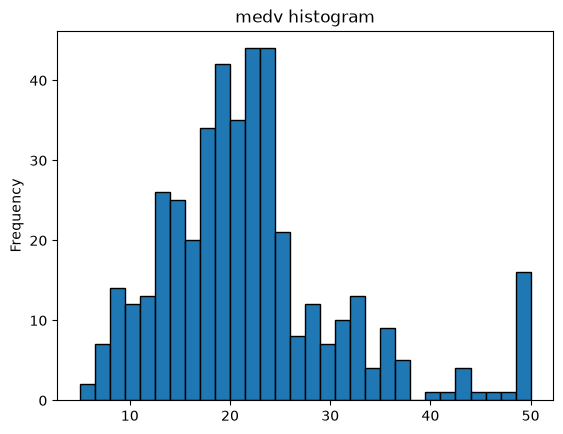

In [ ]:
boston_df[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)

<Axes: title={'center': 'medv boxplot'}>

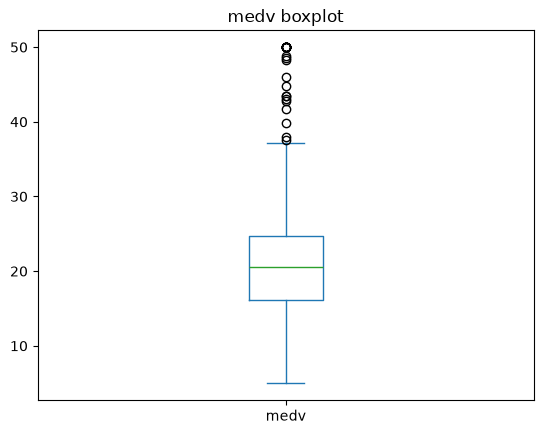

In [22]:
boston_df[column].plot(kind="box", title=f"{column} boxplot")

**Ruido identificado en `crim`:** valores atípicos (outliers) genuinos, no errores de captura —
zonas de criminalidad excepcionalmente alta son plausibles en la realidad, no ruido estocástico.

**Regla de validación propuesta:** `crim >= 0` (no puede ser negativa); valores > 3×IQR desde
Q3 se marcan para revisión, no para eliminación automática.

**Utilidad para el proyecto:** Alta — la criminalidad es un predictor esperado del precio de
vivienda según la literatura inmobiliaria.

### Nota especial: censura en `medv`

El histograma de `medv` muestra una acumulación anómala de 16 registros exactamente en el valor
`50.0`, rompiendo la tendencia decreciente natural de la distribución. Esto es consistente con
el conocido efecto de censura del dataset Boston Housing original: las viviendas con valor real
igual o superior a $50,000 fueron registradas con un techo artificial de $50,000. Esto no es un
outlier ni un error de captura — es una limitación estructural de la fuente de datos, y debe
tenerse en cuenta al evaluar el desempeño del modelo en el rango alto de precios (el modelo
nunca podrá predecir correctamente por encima de 50, porque el dato de entrenamiento tampoco
lo refleja).

<Axes: title={'center': 'chas value counts'}, xlabel='chas'>

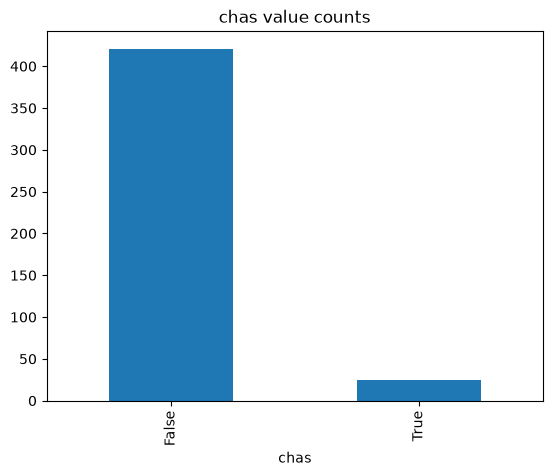

In [23]:
column = "chas"
boston_df[column].describe()
boston_df[column].value_counts()
boston_df[column].value_counts().plot(kind="bar", title=f"{column} value counts")

**Regla de validación:** `chas` solo puede tomar valores {True, False} — cualquier otro valor
es un error de captura.

## Resumen del dataset
- 448 registros, 15 columnas (14 predictoras + `medv` como target)
- Sin filas ni columnas duplicadas
- Nulos dispersos entre 0.2% y 3.6% por columna, ninguna crítica

## Variable objetivo (medv)
[completar con skew/kurtosis/distribución de medv]

## Hallazgos por tipo de ruido
[resumen: cuáles son outliers reales vs. posibles errores]

## ¿Modelo heurístico viable?
[primera intuición: ¿qué combinación simple de 2-3 variables — ej. rm, lstat, crim — podría
aproximar el precio sin ML, como referencia base a superar?]

## Reglas de validación consolidadas
[tabla resumen de todas las reglas identificadas por columna]

## Transformaciones sugeridas para Feature Engineering
[ej. log-transform en crim/dis, escalado en variables con rangos muy distintos]

### Nota sobre el tipo de `rad`

Aunque su dtype técnico es `Int64` (heredado del Paso 2, para preservar los valores nulos como
enteros), `rad` se trata como **variable categórica ordinal** en este análisis, dado que
representa un índice de accesibilidad (9 categorías discretas, incluyendo un salto abrupto de
8 a 24) y no una cantidad continua medible. Se incluye manualmente en el grupo de variables
categóricas para el análisis univariable.

In [ ]:
categorical_columns = [*boston_df.select_dtypes(include=["category"]).columns, "rad"]
numeric_columns = [
    c
    for c in boston_df.select_dtypes(include=["number"]).columns
    if c not in ["ID", "rad"]
]

<Axes: title={'center': 'rad value counts'}, xlabel='rad'>

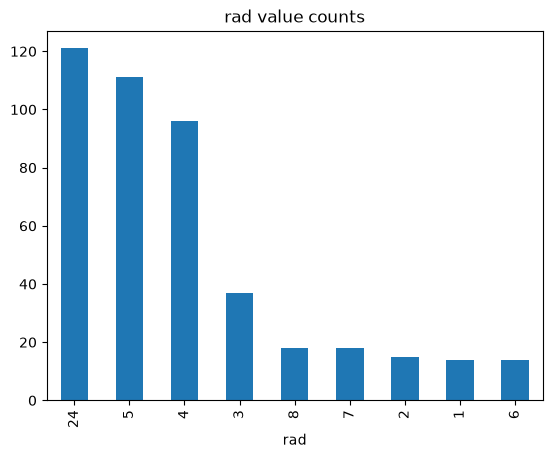

In [26]:
column = "rad"
boston_df[column].describe()
boston_df[column].value_counts()
boston_df[column].value_counts().plot(kind="bar", title=f"{column} value counts")

## Análisis Univariable — Variables Categóricas

### chas (Charles River dummy)

**Hallazgos:**
- Distribución fuertemente desbalanceada: ~420 registros `False` vs. ~25 `True` (~6% del total).
- No hay ruido evidente — es una variable booleana bien definida, sin valores fuera del
  dominio esperado {True, False}.
- **Limitación para etapas posteriores:** con tan pocos casos `True`, cualquier análisis
  bivariable o modelo que dependa de esta variable tendrá baja potencia estadística para el
  grupo minoritario — se debe interpretar con cautela cualquier diferencia observada.
- **Utilidad:** Media — es un predictor plausible (cercanía al río suele influir en el precio),
  pero el desbalance limita su poder explicativo individual.

### rad (índice de accesibilidad a autopistas radiales)

**Hallazgos:**
- 9 categorías distintas: {1, 2, 3, 4, 5, 6, 7, 8, 24}.
- La categoría `24` es la **más frecuente** (~120 registros), seguida de `5` (~110) y `4` (~95);
  las categorías 1, 2, 3, 6, 7, 8 tienen entre 10-40 registros cada una.
- El salto abrupto de `8` a `24` (sin valores intermedios 9-23) confirma que se trata de un
  **índice categórico ordinal**, no de una medida continua — coherente con la definición
  oficial ("index of accessibility to radial highways").
- **Nota de tipo de dato:** aunque su dtype técnico en pandas es `Int64` (por diseño, para
  preservar nulos como enteros desde el Paso 2), se trata funcionalmente como categórica
  ordinal en este análisis.
- **Utilidad:** Media-alta — la accesibilidad a autopistas es un factor típico en modelos de
  valoración inmobiliaria, aunque su relación con el precio podría no ser monotónica (revisar
  en análisis bivariable).

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


### Duplicados

- Filas exactamente duplicadas (incluyendo `ID`): **80**
- Filas duplicadas en las 14 variables reales, ignorando `ID`: **90**
- Columnas duplicadas: **0**
- `ID` no es un identificador verdaderamente único: solo 343 valores únicos en 448 filas.

Esto sugiere que el dataset fue construido concatenando datos de más de una fuente, o de una
misma fuente cargada más de una vez, generando registros duplicados con IDs tanto repetidos
como distintos para el mismo dato real.

**Decisión:** se documenta el hallazgo en esta etapa de exploración, sin eliminar los
duplicados en este notebook. La eliminación (y la definición de si se prioriza `ID` o el
contenido completo de la fila como criterio de deduplicación) se abordará explícitamente en
la etapa de Feature Engineering, donde también se decidirá si `ID` se conserva, se recalcula,
o se descarta por completo del dataset.

   ### Tabla consolidada: ruido, utilidad y reglas de validación

### Tabla consolidada: ruido, utilidad y reglas de validación por variable

*Basada en los hallazgos documentados a lo largo del análisis univariable. Los juicios de
"ruido" y "utilidad" son evaluación experta, no cálculo automático.*

| Variable | Tipo de ruido | Utilidad | Regla de validación |
|---|---|---|---|
| `crim` | Outliers genuinos (zonas de alta criminalidad real) | Alta | `crim >= 0`; candidata a log-transform |
| `zn` | Ninguno relevante; concentrada en 0 | Media | `0 <= zn <= 100` |
| `indus` | Ninguno relevante | Media | `0 <= indus <= 100` |
| `chas` | Ninguno; variable desbalanceada (~6% True) | Media (baja potencia estadística por desbalance) | `chas in {True, False}` |
| `nox` | Corregido: error de escala ×1000 (ver Paso 2) | Alta | `0 < nox <= 1` |
| `rm` | Corregido: error de escala ×1000 (ver Paso 2) | Alta | `rm > 0`; rango plausible 1–15 |
| `age` | Ninguno relevante | Media | `0 <= age <= 100` |
| `dis` | Corregido: error de escala ×1000 (ver Paso 2) | Media | `dis > 0` |
| `rad` | Ninguno; categórica ordinal con salto 8→24 | Media-alta | `rad in {1,2,3,4,5,6,7,8,24}` |
| `tax` | Ninguno relevante; posible bimodalidad | Media | `tax > 0` |
| `ptratio` | Ninguno relevante | Media | `ptratio > 0`; rango plausible 10–25 |
| `black` | Construcción histórica controversial (ver nota ética); asimetría extrema | Pendiente de decisión (ver nota sobre sesgo racial) | `0 <= black <= 396.9` (según fórmula original) |
| `lstat` | Ninguno relevante | Alta | `0 <= lstat <= 100` |
| `medv` | Censura en el techo: valores ≥ 50 registrados como exactamente 50.0 | Variable objetivo (target) | `medv > 0`; interpretar con cautela valores `== 50.0` |

## 💡 Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project


## Transformaciones sugeridas para Feature Engineering

- **Deduplicación**: eliminar las 80 filas exactamente duplicadas (o las 90 duplicadas
  ignorando `ID`, según se decida el criterio) antes de dividir en train/test — de lo
  contrario, el mismo registro podría aparecer tanto en entrenamiento como en validación,
  inflando artificialmente las métricas de desempeño.
- **Tratamiento de `ID`**: dado que no es único, evaluar si se descarta como columna
  (recomendado, ya que tampoco aporta valor predictivo) o si se regenera un identificador
  propio después de deduplicar.
- Log-transform en `crim`, `dis`, `black` (skewness extremo, ver tabla consolidada).
- Considerar el techo de censura en `medv` (valor 50) al evaluar métricas de desempeño del
  modelo final, especialmente en el segmento de precios altos.